## Partie 1 – Exploration du dataset

Pour chaque image : nom, classe, format, mode, largeur, hauteur, écart-type des pixels, nombre de canaux, taille (poids en octets). Gestion des fichiers corrompus.

In [2]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image

RAW_DIR = Path("../data/raw")
CLASSES = sorted([d.name for d in RAW_DIR.iterdir() if d.is_dir()])
print("Classes détectées :", CLASSES)


Classes détectées : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [4]:
def explore_image(path: Path, classe: str) -> dict:
    """Récupère les métadonnées d'une image. Renvoie un dict avec corrupted=True si l'image est illisible."""
    info = {
        "nom": path.name,
        "classe": classe,
        "chemin": str(path),
        "taille_octets": path.stat().st_size if path.exists() else None,
        "format": None,
        "mode": None,
        "largeur": None,
        "hauteur": None,
        "nb_canaux": None,
        "ecart_type_pixels": None,
        "corrompue": False,
    }
    try:
        with Image.open(path) as img:
            img.verify()  # vérifie l'intégrité du fichier (structure)
        # verify() ferme le fichier -> on le rouvre pour lire les données pixel
        with Image.open(path) as img:
            info["format"] = img.format
            info["mode"] = img.mode
            info["largeur"], info["hauteur"] = img.size
            info["nb_canaux"] = len(img.getbands())
            arr = np.array(img.convert(img.mode))
            info["ecart_type_pixels"] = float(np.std(arr))
    except Exception as e:
        info["corrompue"] = True
        info["erreur"] = str(e)
    return info


In [5]:
records = []
for classe in CLASSES:
    class_dir = RAW_DIR / classe
    for path in sorted(class_dir.iterdir()):
        if path.is_file():
            records.append(explore_image(path, classe))

df = pd.DataFrame(records)
print(f"Nombre total d'images explorées : {len(df)}")
df.head()


Nombre total d'images explorées : 1032


,nom,classe,chemin,taille_octets,format,mode,largeur,hauteur,nb_canaux,ecart_type_pixels,corrompue,erreur
0,cardboard1.jpg,cardboard,../data/raw/cardboard/cardboard1.jpg,17333,JPEG,RGB,512.0,384.0,3.0,40.588529,False,NaN
1,cardboard10.jpg,cardboard,../data/raw/cardboard/cardboard10.jpg,21683,JPEG,RGB,512.0,384.0,3.0,42.571288,False,NaN
2,cardboard100.jpg,cardboard,../data/raw/cardboard/cardboard100.jpg,14884,JPEG,RGB,512.0,384.0,3.0,46.108305,False,NaN
3,cardboard101.jpg,cardboard,../data/raw/cardboard/cardboard101.jpg,14289,JPEG,RGB,512.0,384.0,3.0,72.263996,False,NaN
4,cardboard102.jpg,cardboard,../data/raw/cardboard/cardboard102.jpg,18015,JPEG,RGB,512.0,384.0,3.0,48.388937,False,NaN


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   nom                1032 non-null   str    
 1   classe             1032 non-null   str    
 2   chemin             1032 non-null   str    
 3   taille_octets      1032 non-null   int64  
 4   format             1026 non-null   str    
 5   mode               1026 non-null   str    
 6   largeur            1026 non-null   float64
 7   hauteur            1026 non-null   float64
 8   nb_canaux          1026 non-null   float64
 9   ecart_type_pixels  1026 non-null   float64
 10  corrompue          1032 non-null   bool   
 11  erreur             6 non-null      str    
dtypes: bool(1), float64(4), int64(1), str(6)
memory usage: 89.8 KB


## Partie 2 – Détecter les images corrompues

On écrit une fonction dédiée `is_corrupted` qui tente d'ouvrir et de décoder complètement une image. Une image est considérée corrompue si son fichier existe mais ne peut pas être lu correctement par PIL (en-tête invalide, données tronquées, fichier vide, etc.).

In [9]:
def is_corrupted(path: Path) -> bool:
    """Renvoie True si l'image ne peut pas être ouverte ET décodée correctement."""
    try:
        with Image.open(path) as img:
            img.verify()
        # verify() ne décode pas les pixels, on force la lecture complète des données
        with Image.open(path) as img:
            img.load()
        return False
    except Exception:
        return True


In [10]:
# On applique la fonction à l'ensemble du dataset (indépendamment du DataFrame de la Partie 1,
# pour bien répondre à la consigne "écrire ET se servir d'une fonction dédiée")
corrupted_images = []
for classe in CLASSES:
    class_dir = RAW_DIR / classe
    for path in sorted(class_dir.iterdir()):
        if path.is_file() and is_corrupted(path):
            corrupted_images.append({"nom": path.name, "classe": classe, "chemin": str(path)})

df_corrupted = pd.DataFrame(corrupted_images)
print(f"Nombre d'images corrompues détectées : {len(df_corrupted)}")
df_corrupted


Nombre d'images corrompues détectées : 6


,nom,classe,chemin
0,cardboard83.jpg,cardboard,../data/raw/cardboard/cardboard83.jpg
1,glass74.jpg,glass,../data/raw/glass/glass74.jpg
2,metal48.jpg,metal,../data/raw/metal/metal48.jpg
3,paper213.jpg,paper,../data/raw/paper/paper213.jpg
4,plastic13.jpg,plastic,../data/raw/plastic/plastic13.jpg
5,trash3.jpg,trash,../data/raw/trash/trash3.jpg


In [11]:
# Cohérence avec la colonne 'corrompue' calculée à la Partie 1
assert len(df_corrupted) == df["corrompue"].sum(), "Incohérence entre les deux méthodes de détection"
print("Cohérence vérifiée avec le DataFrame de la Partie 1.")


Cohérence vérifiée avec le DataFrame de la Partie 1.


## Partie 3 – Détecter les images vides

Une image est considérée comme « vide » si elle est entièrement noire, entièrement blanche, ou si ses pixels présentent très peu de variation (image quasi uniforme). On utilise l'écart-type des pixels comme critère principal, complété par la valeur moyenne pour distinguer noir/blanc.

In [12]:

SEUIL_ECART_TYPE = 5.0        # écart-type des pixels en dessous duquel on juge l'image "plate"
SEUIL_NOIR = 10.0             # moyenne des pixels proche de 0 -> image noire
SEUIL_BLANC = 245.0           # moyenne des pixels proche de 255 -> image blanche

def is_empty_image(path: Path) -> dict:
    """Détecte si une image est vide (noire, blanche ou quasi uniforme).
    Renvoie un dict avec le diagnostic ; ignore silencieusement les images corrompues
    (déjà traitées par is_corrupted à la Partie 2)."""
    result = {"vide": False, "raison": None, "moyenne": None, "ecart_type": None}
    try:
        with Image.open(path) as img:
            arr = np.array(img.convert("L"))  # niveaux de gris pour un critère unique et simple
        moyenne = float(arr.mean())
        ecart_type = float(arr.std())
        result["moyenne"] = moyenne
        result["ecart_type"] = ecart_type

        if moyenne <= SEUIL_NOIR and ecart_type <= SEUIL_ECART_TYPE:
            result["vide"], result["raison"] = True, "noire"
        elif moyenne >= SEUIL_BLANC and ecart_type <= SEUIL_ECART_TYPE:
            result["vide"], result["raison"] = True, "blanche"
        elif ecart_type <= SEUIL_ECART_TYPE:
            result["vide"], result["raison"] = True, "quasi uniforme"
    except Exception:
        pass  # image corrompue : hors périmètre de cette détection
    return result


In [13]:
empty_records = []
for classe in CLASSES:
    class_dir = RAW_DIR / classe
    for path in sorted(class_dir.iterdir()):
        if not path.is_file() or is_corrupted(path):
            continue
        diag = is_empty_image(path)
        if diag["vide"]:
            empty_records.append({
                "nom": path.name, "classe": classe, "chemin": str(path),
                "raison": diag["raison"], "moyenne": diag["moyenne"], "ecart_type": diag["ecart_type"],
            })

df_empty = pd.DataFrame(empty_records)
print(f"Nombre d'images vides détectées : {len(df_empty)}")
df_empty


Nombre d'images vides détectées : 4


,nom,classe,chemin,raison,moyenne,ecart_type
0,image-blanche-512x384.jpg,cardboard,../data/raw/cardboard/image-blanche-512x384.jpg,blanche,254.958211,1.132032
1,image-noire-512x384.png,glass,../data/raw/glass/image-noire-512x384.png,noire,0.000000,0.000000
2,image-blanche-512x384.jpg,metal,../data/raw/metal/image-blanche-512x384.jpg,blanche,254.958211,1.132032
3,image-noire-512x384.png,metal,../data/raw/metal/image-noire-512x384.png,noire,0.000000,0.000000


## Partie 4 – Détecter les différences de résolution

On réutilise le DataFrame `df` de la Partie 1 (colonnes `largeur`/`hauteur`), en excluant les images corrompues qui n'ont pas de résolution exploitable.

In [14]:
df_valid = df[~df["corrompue"]].copy()
df_valid["resolution"] = list(zip(df_valid["largeur"].astype(int), df_valid["hauteur"].astype(int)))

res_min_largeur = df_valid["largeur"].min()
res_min_hauteur = df_valid["hauteur"].min()
res_max_largeur = df_valid["largeur"].max()
res_max_hauteur = df_valid["hauteur"].max()

print(f"Résolution minimale observée : {int(df_valid.loc[df_valid['largeur'].idxmin(), 'largeur'])}x{int(df_valid.loc[df_valid['largeur'].idxmin(), 'hauteur'])} (largeur min) / "
      f"{int(df_valid.loc[df_valid['hauteur'].idxmin(), 'largeur'])}x{int(df_valid.loc[df_valid['hauteur'].idxmin(), 'hauteur'])} (hauteur min)")
print(f"Résolution maximale observée : {int(df_valid.loc[df_valid['largeur'].idxmax(), 'largeur'])}x{int(df_valid.loc[df_valid['largeur'].idxmax(), 'hauteur'])} (largeur max) / "
      f"{int(df_valid.loc[df_valid['hauteur'].idxmax(), 'largeur'])}x{int(df_valid.loc[df_valid['hauteur'].idxmax(), 'hauteur'])} (hauteur max)")


Résolution minimale observée : 32x32 (largeur min) / 48x32 (hauteur min)
Résolution maximale observée : 512x384 (largeur max) / 512x384 (hauteur max)


In [15]:
resolution_counts = df_valid["resolution"].value_counts()
print("Résolutions les plus fréquentes :")
resolution_counts.head(10)


Résolutions les plus fréquentes :


resolution
(512, 384)    1013
(32, 32)         5
(48, 32)         4
(40, 40)         4
Name: count, dtype: int64

In [16]:
print(f"Nombre total de résolutions distinctes : {df_valid['resolution'].nunique()}")


Nombre total de résolutions distinctes : 4


### Images sous la résolution minimale requise (64×64)


In [17]:
SEUIL_MIN = 64
df_trop_petites = df_valid[(df_valid["largeur"] < SEUIL_MIN) | (df_valid["hauteur"] < SEUIL_MIN)]
print(f"Nombre d'images trop petites (< {SEUIL_MIN}x{SEUIL_MIN}) : {len(df_trop_petites)}")
df_trop_petites[["nom", "classe", "largeur", "hauteur"]]


Nombre d'images trop petites (< 64x64) : 13


,nom,classe,largeur,hauteur
20,cardboard117.jpg,cardboard,48.0,32.0
77,cardboard22.jpg,cardboard,32.0,32.0
133,cardboard70.jpg,cardboard,40.0,40.0
171,glass100.jpg,glass,40.0,40.0
229,glass15.jpg,glass,48.0,32.0
268,glass21.jpg,glass,32.0,32.0
270,glass23.jpg,glass,32.0,32.0
383,metal121.jpg,metal,48.0,32.0
413,metal2.jpg,metal,32.0,32.0
421,metal26.jpg,metal,40.0,40.0


## Partie 5 – Détecter les différents canaux

On s'appuie sur les colonnes `nb_canaux` et `mode` calculées à la Partie 1, en excluant les images corrompues.

In [18]:
print("Nombre d'images par nombre de canaux :")
df_valid["nb_canaux"].value_counts().sort_index()


Nombre d'images par nombre de canaux :


nb_canaux
1.0       2
3.0    1006
4.0      18
Name: count, dtype: int64

In [19]:
print("Détail par mode PIL (L=grayscale, RGB, RGBA, P=palette, etc.) :")
df_valid["mode"].value_counts()


Détail par mode PIL (L=grayscale, RGB, RGBA, P=palette, etc.) :


mode
RGB     1006
RGBA      18
P          2
Name: count, dtype: int64

In [20]:
nb_grayscale = int((df_valid["nb_canaux"] == 1).sum())
nb_rgb = int((df_valid["nb_canaux"] == 3).sum())
nb_rgba = int((df_valid["nb_canaux"] == 4).sum())

print(f"Images en grayscale (1 canal) : {nb_grayscale}")
print(f"Images en RGB (3 canaux)      : {nb_rgb}")
print(f"Images en RGBA (4 canaux)     : {nb_rgba}")
print(f"Autres nombres de canaux      : {len(df_valid) - nb_grayscale - nb_rgb - nb_rgba}")


Images en grayscale (1 canal) : 2
Images en RGB (3 canaux)      : 1006
Images en RGBA (4 canaux)     : 18
Autres nombres de canaux      : 0


## Partie 6 – Détecter les doublons

**Attention** : deux fichiers différents (noms différents, formats différents) peuvent contenir exactement la même image. On ne peut donc pas se contenter de comparer les noms de fichiers ou de hasher les octets bruts du fichier (un même visuel enregistré en `.jpg` puis en `.png` aurait des octets différents). On hashe plutôt le **contenu pixel décodé**, après conversion vers un mode commun (RGB), pour détecter les doublons visuels exacts, même entre classes différentes.

In [21]:
import hashlib

def hash_pixels(path: Path) -> str:
    """Hash MD5 du contenu pixel décodé (après conversion RGB), pour détecter les doublons
    visuels exacts indépendamment du format de fichier ou du mode d'origine."""
    with Image.open(path) as img:
        arr = np.array(img.convert("RGB"))
    return hashlib.md5(arr.tobytes()).hexdigest()


In [22]:
hash_records = []
for classe in CLASSES:
    class_dir = RAW_DIR / classe
    for path in sorted(class_dir.iterdir()):
        if not path.is_file() or is_corrupted(path):
            continue
        try:
            h = hash_pixels(path)
            hash_records.append({"nom": path.name, "classe": classe, "chemin": str(path), "hash": h})
        except Exception:
            continue

df_hash = pd.DataFrame(hash_records)

# Groupes de doublons : hash partagé par au moins 2 fichiers
groupes_doublons = df_hash.groupby("hash").filter(lambda g: len(g) > 1)
nb_groupes = groupes_doublons["hash"].nunique()
nb_fichiers_dupliques = len(groupes_doublons)

print(f"Nombre de groupes de doublons : {nb_groupes}")
print(f"Nombre total de fichiers impliqués dans un doublon : {nb_fichiers_dupliques}")
groupes_doublons.sort_values("hash")[["hash", "nom", "classe"]]


Nombre de groupes de doublons : 15
Nombre total de fichiers impliqués dans un doublon : 30


,hash,nom,classe
975,020356755d7631716228a952bf3c3ead,plasticx199.jpg,plastic
864,020356755d7631716228a952bf3c3ead,plastic199.jpg,plastic
257,03b62f7033ed13e63138ebd048abc4ea,glass176.jpg,glass
812,03b62f7033ed13e63138ebd048abc4ea,plastic152.jpg,plastic
728,116e03527a54192f3693d884d259d23b,paper77ty.jpg,paper
727,116e03527a54192f3693d884d259d23b,paper77.jpg,paper
385,16e737d7e848620a6e96cc7e4f75dd37,metal125.jpg,metal
386,16e737d7e848620a6e96cc7e4f75dd37,metal125po.jpg,metal
167,22a0ea89c32ebdf57e195d9d0b8da9d6,image-violet-512x384.gif,cardboard
354,22a0ea89c32ebdf57e195d9d0b8da9d6,image-violet-512x384.gif,glass


On remarque que certains doublons traversent plusieurs classes (ex. `image-blanche-512x384.jpg` présente dans `cardboard` **et** `metal`, `image-noire-512x384.png` dans `glass` **et** `metal`) — ce sont très probablement des images mal classées plutôt que de vrais doublons intra-classe. À recroiser avec la Partie 7.

## Partie 7 – Détecter les images mal classées

Le contrôle visuel exhaustif de 1032 images n'est pas réaliste à la main. On procède en deux temps :

1. **Candidats forts, automatiques** : les doublons inter-classes détectés à la Partie 6 sont quasiment toujours des erreurs de tri (la même image ne peut logiquement appartenir qu'à une seule classe).
2. **Outil de contrôle visuel** : une fonction d'affichage en grille pour parcourir chaque classe par lots et repérer les intrus à l'œil.

In [23]:
import matplotlib.pyplot as plt

def afficher_grille(paths_et_labels, cols=6, taille_case=2.2, titre=None):
    """Affiche une grille de miniatures avec leur classe/nom en légende, pour contrôle visuel."""
    n = len(paths_et_labels)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * taille_case, rows * taille_case))
    axes = axes.flatten() if n > 1 else [axes]
    if titre:
        fig.suptitle(titre)
    for ax, (path, label) in zip(axes, paths_et_labels):
        try:
            with Image.open(path) as img:
                ax.imshow(img.convert("RGB"))
        except Exception:
            ax.text(0.5, 0.5, "illisible", ha="center", va="center")
        ax.set_title(label, fontsize=8)
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [24]:
# On isole, parmi les groupes de doublons de la Partie 6, ceux qui traversent plusieurs classes
suspects_mauvais_classement = []
for h, groupe in groupes_doublons.groupby("hash"):
    if groupe["classe"].nunique() > 1:
        suspects_mauvais_classement.append(groupe)

df_suspects = pd.concat(suspects_mauvais_classement) if suspects_mauvais_classement else pd.DataFrame()
print(f"Groupes de doublons traversant plusieurs classes : {df_suspects['hash'].nunique() if len(df_suspects) else 0}")
df_suspects[["hash", "nom", "classe"]] if len(df_suspects) else df_suspects


Groupes de doublons traversant plusieurs classes : 5


,hash,nom,classe
257,03b62f7033ed13e63138ebd048abc4ea,glass176.jpg,glass
812,03b62f7033ed13e63138ebd048abc4ea,plastic152.jpg,plastic
167,22a0ea89c32ebdf57e195d9d0b8da9d6,image-violet-512x384.gif,cardboard
354,22a0ea89c32ebdf57e195d9d0b8da9d6,image-violet-512x384.gif,glass
187,50035a9538d7667528ee3461c83ef8e1,glass115.jpg,glass
493,50035a9538d7667528ee3461c83ef8e1,metal91.jpg,metal
166,51de3f59d442ffb18d7f2365e9e69d7c,image-blanche-512x384.jpg,cardboard
355,51de3f59d442ffb18d7f2365e9e69d7c,image-blanche-512x384.jpg,metal
353,79fcad4e94ed64b1d285c7da6bbac73c,image-noire-512x384.png,glass
356,79fcad4e94ed64b1d285c7da6bbac73c,image-noire-512x384.png,metal


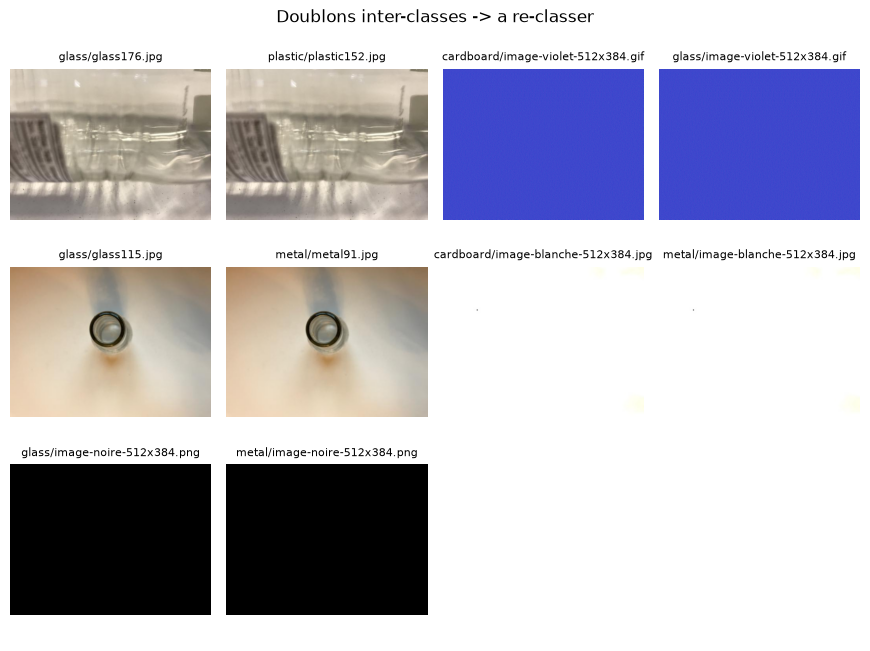

In [25]:
# Contrôle visuel de ces candidats
if len(df_suspects):
    paires = [(row["chemin"], f"{row['classe']}/{row['nom']}") for _, row in df_suspects.iterrows()]
    afficher_grille(paires, cols=4, titre="Doublons inter-classes -> a re-classer")


**Conclusion du contrôle visuel** : `glass176.jpg` et `glass115.jpg` (classe `glass`) montrent bien des bouteilles en verre — la classe `glass` est correcte. Leurs doublons `plastic152.jpg` et `metal91.jpg` sont donc **mal classés** et devraient être déplacés vers `glass`. Les trois images de test (blanche/noire/violette) présentes dans plusieurs classes n'appartiennent à aucune catégorie réelle et seront traitées comme des images à exclure plutôt qu'à reclasser.

### Outil de contrôle visuel par classe (échantillonnage)

Pour aller plus loin, on peut parcourir chaque classe par lots de 24 images afin de repérer d'autres intrus non détectés par le hachage (ex. une image visuellement proche d'une autre classe mais pas strictement identique).

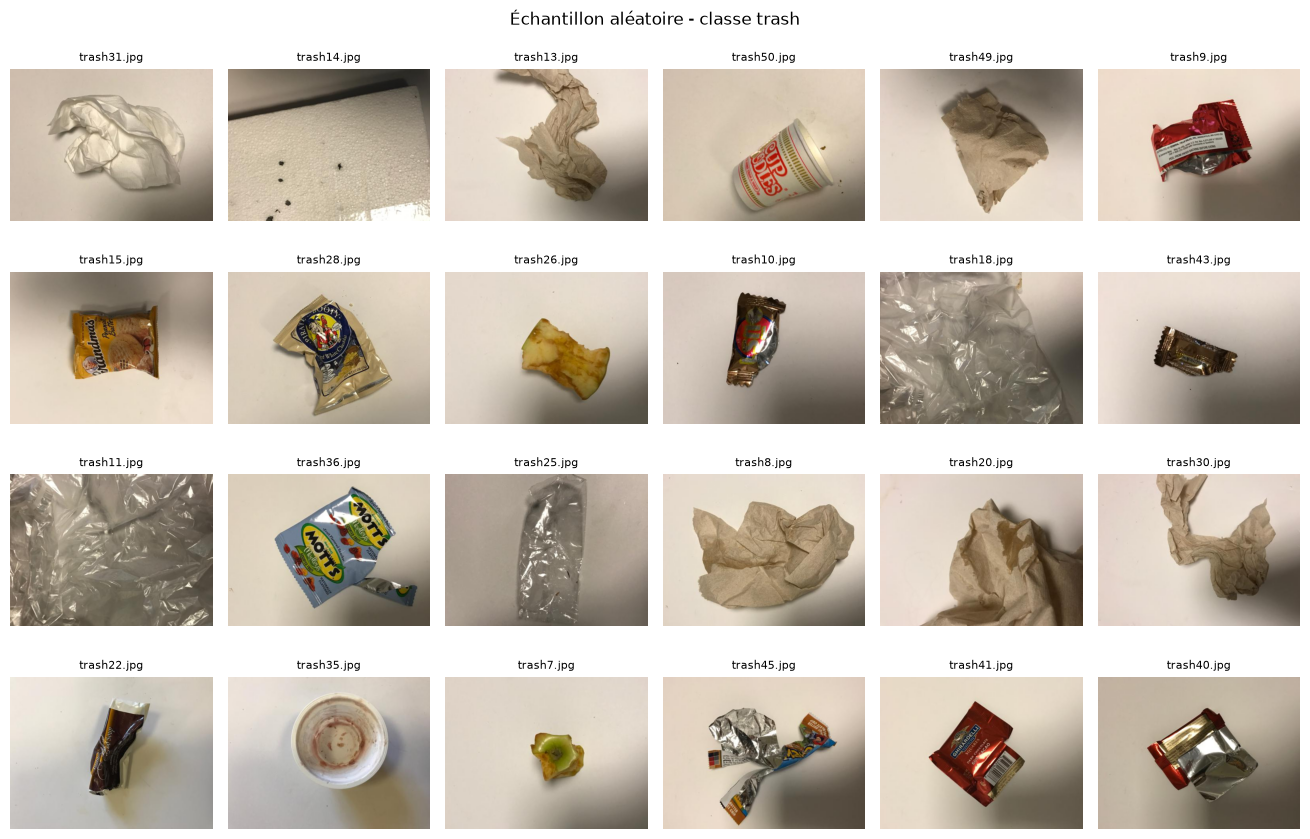

In [26]:
import random

def controle_visuel_classe(classe: str, n=24, seed=42):
    random.seed(seed)
    fichiers = [p for p in (RAW_DIR / classe).iterdir() if p.is_file() and not is_corrupted(p)]
    echantillon = random.sample(fichiers, min(n, len(fichiers)))
    paires = [(p, p.name) for p in echantillon]
    afficher_grille(paires, cols=6, titre=f"Échantillon aléatoire - classe {classe}")

# Exemple d'utilisation (à répéter pour chaque classe lors du contrôle visuel complet) :
controle_visuel_classe("trash")
